In [ ]:
import os
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

# A. Training pipeline

In [66]:
# 1) import dan load data
PATH = "data/ngsim_trajectory.csv"

usecols = [
    "Vehicle_ID","Global_Time","Lane_ID",
    "Preceding_Vehicle","Spacing","Headway",
    "Vehicle_Velocity","Vehicle_Acceleration"
]

dtypes = {
    "Vehicle_ID": "int32",
    "Global_Time": "int64",
    "Lane_ID": "int16",
    "Preceding_Vehicle": "int32",
    "Spacing": "float32",
    "Headway": "float32",
    "Vehicle_Velocity": "float32",
    "Vehicle_Acceleration": "float32"
}

df = pd.read_csv(PATH, usecols=usecols, dtype=dtypes)
print("Loaded:", df.shape)
df.head()

Loaded: (1180598, 8)


,Vehicle_ID,Global_Time,Vehicle_Velocity,Vehicle_Acceleration,Lane_ID,Preceding_Vehicle,Spacing,Headway
0,2,1118846980200,40.0,0.0,2,0,0.0,0.0
1,2,1118846980300,40.0,0.0,2,0,0.0,0.0
2,2,1118846980400,40.0,0.0,2,0,0.0,0.0
3,2,1118846980500,40.0,0.0,2,0,0.0,0.0
4,2,1118846980600,40.0,0.0,2,0,0.0,0.0


In [ ]:
# 2) EDA cek data valid
print("Preceding==0:", (df["Preceding_Vehicle"]==0).mean())
print("Spacing<=0:", (df["Spacing"]<=0).mean())
print("Headway<=0:", (df["Headway"]<=0).mean())
print("Headway>=10:", (df["Headway"]>=10).mean())  # biasanya termasuk 9999.99
print("Velocity<=0:", (df["Vehicle_Velocity"]<=0).mean())

Preceding==0: 0.050297391660836285
Spacing<=0: 0.050299085717577026
Headway<=0: 0.05032957873891028
Headway>=10: 0.025088133301936814
Velocity<=0: 0.01650519482499547


In [20]:
# 3) cleaning
dfc = df[
    (df["Preceding_Vehicle"] != 0) &
    (df["Spacing"] > 0) &
    (df["Headway"] > 0) &
    (df["Headway"] < 10) &           # buang 9999.99 dan nilai ekstrem
    (df["Vehicle_Velocity"] > 0)     # opsional tapi bikin fitur stabil
].copy()

print("Before:", df.shape, "After cleaning:", dfc.shape)

Before: (1180598, 8) After cleaning: (1091560, 8)


menggunakan data saat ada kendaraan di depan dan nilai sensor masuk akal; nilai 0 atau ekstrem dibuang agar model tidak belajar dari noise.

In [21]:
# 4) Konversi satuan
FEET_TO_M = 0.3048

dfc["timestamp"] = dfc["Global_Time"] / 1000.0
dfc["d_front_m"] = dfc["Spacing"] * FEET_TO_M
dfc["v_ego_ms"]  = dfc["Vehicle_Velocity"] * FEET_TO_M
dfc["acc_ms2"]   = dfc["Vehicle_Acceleration"] * FEET_TO_M

dfc = dfc.sort_values(["Vehicle_ID","timestamp"]).reset_index(drop=True)
dfc.head()

,Vehicle_ID,Global_Time,Vehicle_Velocity,Vehicle_Acceleration,Lane_ID,Preceding_Vehicle,Spacing,Headway,timestamp,d_front_m,v_ego_ms,acc_ms2
0,6,1118846993000,45.150002,0.0,7,4,56.990002,1.26,1.118847e+09,17.370552,13.761721,0.0
1,6,1118846993100,45.150002,0.0,7,4,56.939999,1.26,1.118847e+09,17.355312,13.761721,0.0
2,6,1118846993200,45.150002,0.0,7,4,56.830002,1.26,1.118847e+09,17.321785,13.761721,0.0
3,6,1118846993300,45.150002,0.0,7,4,56.639999,1.25,1.118847e+09,17.263872,13.761721,0.0
4,6,1118846993400,45.150002,0.0,7,4,56.360001,1.25,1.118847e+09,17.178528,13.761721,0.0


In [22]:
# 5) Feature engineering
# a. closing speed (seberapa cepat jarak mengecil)
dt = dfc.groupby("Vehicle_ID")["timestamp"].diff()
dd = dfc.groupby("Vehicle_ID")["d_front_m"].diff()

dfc["dt"] = dt
dfc["closing_speed"] = (-dd / dt).replace([np.inf, -np.inf], np.nan)

# buang dt tidak wajar (NGSIM biasanya ~0.1 detik)
dfc = dfc[(dfc["dt"] > 0) & (dfc["dt"] < 1)].copy()
dfc = dfc.dropna(subset=["closing_speed"])

# clip ekstrem biar tidak kebanyakan outlier
dfc["closing_speed"] = dfc["closing_speed"].clip(lower=-50, upper=50)

print("After closing_speed:", dfc.shape)

After closing_speed: (1088624, 14)


menambah fitur ‘seberapa cepat jarak mengecil’ untuk mendeteksi kondisi makin berbahaya

In [36]:
dfc["dt"].describe()

count    1.088624e+06
mean     1.001456e-01
std      8.849131e-03
min      9.999990e-02
25%      9.999990e-02
50%      9.999990e-02
75%      1.000001e-01
max      9.000001e-01
Name: dt, dtype: float64

In [23]:
# b. window features
# Window = rolling per kendaraan. NGSIM ~10 Hz → 1 detik ≈ 10 sampel.
# Kita pakai rolling 10 (kalau Hz beda, masih oke sebagai proxy).

W = 10  # ~1 detik untuk NGSIM 10Hz

g = dfc.groupby("Vehicle_ID", group_keys=False)

dfc["min_d_front_1s"] = g["d_front_m"].rolling(W, min_periods=1).min().reset_index(level=0, drop=True)
dfc["med_d_front_1s"] = g["d_front_m"].rolling(W, min_periods=1).median().reset_index(level=0, drop=True)
dfc["max_close_1s"]   = g["closing_speed"].rolling(W, min_periods=1).max().reset_index(level=0, drop=True)

# indikator waktu sederhana (tanpa pakai headway): jarak / speed
eps = 0.1
dfc["time_to_reach_1s"] = dfc["min_d_front_1s"] / np.maximum(dfc["v_ego_ms"], eps)

NAVIENTA merangkum data dalam window 1 detik (min/median jarak dan maksimum laju mendekat), supaya output lebih stabil

In [24]:
# 6) Buat label
def label_3class(h):
    if h < 1.0: return "HIGH"
    if h < 2.0: return "MEDIUM"
    return "LOW"

dfc["risk_class"] = dfc["Headway"].apply(label_3class)

dfc["risk_class"].value_counts(normalize=True)

risk_class
LOW       0.525314
MEDIUM    0.438734
HIGH      0.035953
Name: proportion, dtype: float64

Karena belum ada label manual, prototipe memakai aturan headway (2-second rule) untuk membentuk label awal.

In [25]:
# 7) menyiapkan dataset training
FEATURES = [
    "d_front_m","v_ego_ms","acc_ms2",
    "closing_speed",
    "min_d_front_1s","med_d_front_1s","max_close_1s",
    "time_to_reach_1s",
    "Lane_ID"
]
TARGET = "risk_class"

train_df = dfc[["Vehicle_ID","timestamp"] + FEATURES + [TARGET]].dropna().copy()
print("Train_df:", train_df.shape)

Train_df: (1088624, 12)


In [ ]:
# 8) split data by Vehicle_ID

vids = train_df["Vehicle_ID"].unique()
train_vids, test_vids = train_test_split(vids, test_size=0.2, random_state=42)

tr = train_df[train_df["Vehicle_ID"].isin(train_vids)]
te = train_df[train_df["Vehicle_ID"].isin(test_vids)]

X_train = tr[FEATURES]
y_train = tr[TARGET]
X_test  = te[FEATURES]
y_test  = te[TARGET]

print("Train rows:", tr.shape, "Test rows:", te.shape)

Train rows: (869546, 12) Test rows: (219078, 12)


In [ ]:
# pastikan tidak ada Vehicle_ID yang sama muncul di train dan test
overlap = set(tr["Vehicle_ID"]).intersection(set(te["Vehicle_ID"]))
print("Overlap Vehicle_ID count:", len(overlap))

# lihat jumlah kendaraan dan jumlah baris
print("Unique Vehicle_ID - train:", tr["Vehicle_ID"].nunique())
print("Unique Vehicle_ID - test :", te["Vehicle_ID"].nunique())
print("Rows - train:", len(tr), "Rows - test:", len(te))

Overlap Vehicle_ID count: 0
Unique Vehicle_ID - train: 1732
Unique Vehicle_ID - test : 433
Rows - train: 869546 Rows - test: 219078


In [27]:
# 9) train & metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)
rf.fit(X_train, y_train)

pred = rf.predict(X_test)
print(classification_report(y_test, pred, digits=4))
print(confusion_matrix(y_test, pred, labels=["LOW","MEDIUM","HIGH"]))

              precision    recall  f1-score   support

        HIGH     0.9868    0.9893    0.9880      7265
         LOW     0.9979    0.9963    0.9971    116525
      MEDIUM     0.9946    0.9964    0.9955     95288

    accuracy                         0.9961    219078
   macro avg     0.9931    0.9940    0.9936    219078
weighted avg     0.9961    0.9961    0.9961    219078

[[116092    433      0]
 [   246  94946     96]
 [     0     78   7187]]


In [28]:
# 10) save model
os.makedirs("model", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

joblib.dump(rf, "model/navienta_rf.joblib")

# simpan metrics ringkas
with open("outputs/metrics.txt","w") as f:
    f.write(classification_report(y_test, pred, digits=4))

# buat file demo 1 kendaraan untuk dashboard (biar ringan)
top_vid = train_df["Vehicle_ID"].value_counts().index[0]
demo = train_df[train_df["Vehicle_ID"]==top_vid].sort_values("timestamp").copy()

demo["pred_class"] = rf.predict(demo[FEATURES])
demo.to_csv("outputs/navienta_demo.csv", index=False)

print("Saved: model/navienta_rf.joblib, outputs/metrics.txt, outputs/navienta_demo.csv")

Saved: model/navienta_rf.joblib, outputs/metrics.txt, outputs/navienta_demo.csv


# B. Produk Insight


In [58]:
# 1) load file demo 
demo = pd.read_csv("outputs/navienta_demo_with_pred.csv")
demo = demo.sort_values("timestamp").reset_index(drop=True)
demo.head()

,Vehicle_ID,timestamp,d_front_m,v_ego_ms,acc_ms2,closing_speed,min_d_front_1s,med_d_front_1s,max_close_1s,time_to_reach_1s,Lane_ID,risk_class,pred_class
0,2625,1.118848e+09,13.655040,9.144,0.0,0.914403,13.655040,13.655040,0.914403,1.493333,2,MEDIUM,MEDIUM
1,2625,1.118848e+09,13.520928,9.144,0.0,1.341112,13.520928,13.587984,1.341112,1.478667,2,MEDIUM,MEDIUM
2,2625,1.118848e+09,13.356336,9.144,0.0,1.645929,13.356336,13.520928,1.645929,1.460667,2,MEDIUM,MEDIUM
3,2625,1.118848e+09,13.176504,9.144,0.0,1.798317,13.176504,13.438632,1.798317,1.441000,2,MEDIUM,MEDIUM
4,2625,1.118848e+09,12.990576,9.144,0.0,1.859281,12.990576,13.356336,1.859281,1.420667,2,MEDIUM,MEDIUM


In [59]:
# membuat waktu relatif
demo["t_rel"] = demo["timestamp"] - demo["timestamp"].min()

In [60]:
# merapikan jarak ekstrem untuk visualisasi
demo["d_front_m_clip"] = demo["d_front_m"].clip(lower=0.5, upper=200)
demo["min_d_front_1s_clip"] = demo["min_d_front_1s"].clip(lower=0.5, upper=200)

In [62]:
# Smoothing prediksi dengan rolling median (window 1 detik) untuk mengurangi noise
risk_map = {"LOW":0, "MEDIUM":1, "HIGH":2}
inv_map = {0:"LOW", 1:"MEDIUM", 2:"HIGH"}

demo["risk_num"] = demo["pred_class"].map(risk_map)

W = 10  # 1 detik
demo["risk_num_smooth"] = demo["risk_num"].rolling(W, min_periods=1).median().round().astype(int)
demo["pred_smooth"] = demo["risk_num_smooth"].map(inv_map)

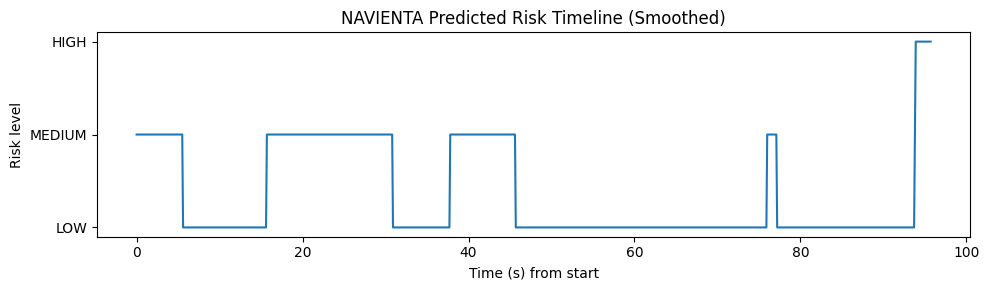

In [63]:
# Buat grafik timelin
plt.figure(figsize=(10,3))
plt.plot(demo["t_rel"].head(5000), demo["pred_smooth"].map(risk_map).head(5000))
plt.yticks([0,1,2], ["LOW","MEDIUM","HIGH"])
plt.xlabel("Time (s) from start")
plt.ylabel("Risk level")
plt.title("NAVIENTA Predicted Risk Timeline (Smoothed)")
plt.tight_layout()
plt.savefig("outputs/pred_risk_timeline_clean.png", dpi=200)
plt.show()

In [64]:
# Buat tabel segmen HIGH (start-end-duration)
is_high = (demo["pred_smooth"]=="HIGH").astype(int)
seg_id = (is_high.diff().fillna(0)==1).cumsum()
demo["seg_id"] = seg_id.where(is_high==1, 0)

segments = (demo[demo["seg_id"]!=0]
            .groupby("seg_id")
            .agg(start_s=("t_rel","min"),
                 end_s=("t_rel","max"),
                 duration_s=("t_rel", lambda s: s.max()-s.min()),
                 min_d_m=("min_d_front_1s_clip","min"),
                 max_close=("max_close_1s","max"))
            .reset_index(drop=True)
            .sort_values("duration_s", ascending=False))

segments.to_csv("outputs/high_segments_clean.csv", index=False)
segments.head(10)

,start_s,end_s,duration_s,min_d_m,max_close
0,93.9,95.7,1.8,0.5,50.0


# C. Insight Model


1) Insight #1 — Feature Importance (top features)

time_to_reach_1s    0.611504
v_ego_ms            0.128670
d_front_m           0.117242
min_d_front_1s      0.065464
med_d_front_1s      0.052475
max_close_1s        0.012900
closing_speed       0.007506
Lane_ID             0.002718
acc_ms2             0.001520
dtype: float64


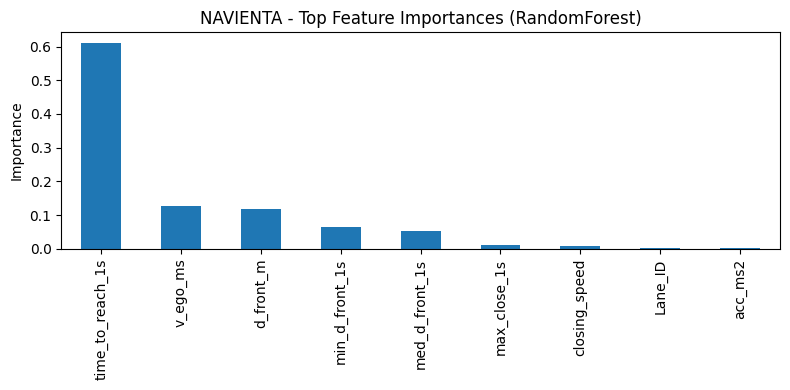

In [ ]:
# 12 — Ambil importance dan simpan grafik
import pandas as pd
import matplotlib.pyplot as plt

# rf = model kamu
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

print(importances.head(10))

plt.figure(figsize=(8,4))
importances.head(10).plot(kind="bar")
plt.title("NAVIENTA - Top Feature Importances (RandomForest)")
plt.ylabel("Importance")
plt.tight_layout()
plt.savefig("outputs/feature_importance.png", dpi=200)
plt.show()

Model paling banyak menentukan risiko dari indikator waktu pendekatan (time-to-reach) dan jarak minimum dalam window 1 detik, artinya NAVIENTA menilai bukan hanya jarak saat ini, tapi juga seberapa cepat kondisi memburuk.

top 3 fitur, model menilai waktu pendekatan + jarak + kecepatan

NAVIENTA merangkum output menjadi segmen bahaya. Pada demo vehicle, segmen HIGH terdeteksi selama ~2.3 detik dengan jarak minimum ~0.18 m dan laju mendekat maksimum tinggi.

3) Insight #2 — Error analysis 

In [ ]:
# 2 — Temukan contoh kasus salah prediksi
from sklearn.metrics import confusion_matrix

# bikin dataframe evaluasi dari test set
te_eval = te.copy()
te_eval["pred"] = pred  # pred dari X_test
te_eval["true"] = y_test.values

# contoh salah: true=MEDIUM tapi pred=LOW
wrong = te_eval[(te_eval["true"]=="MEDIUM") & (te_eval["pred"]=="LOW")].head(20)
wrong[["timestamp","d_front_m","v_ego_ms","closing_speed","min_d_front_1s","max_close_1s","true","pred"]]

,timestamp,d_front_m,v_ego_ms,closing_speed,min_d_front_1s,max_close_1s,true,pred
4836,1.118847e+09,29.053535,14.651736,-0.579129,28.696920,-0.304795,MEDIUM,LOW
4837,1.118847e+09,29.117544,14.630400,-0.640086,28.730450,-0.304795,MEDIUM,LOW
4844,1.118847e+09,29.544264,14.859000,-0.457191,28.995623,-0.457191,MEDIUM,LOW
8710,1.118847e+09,21.555456,10.823447,-2.438414,19.449289,-2.225020,MEDIUM,LOW
8713,1.118847e+09,22.283928,11.177015,-2.225039,20.147280,-2.225020,MEDIUM,LOW
17122,1.118847e+09,19.053047,9.610344,-1.188715,18.729961,0.152397,MEDIUM,LOW
17123,1.118847e+09,19.159729,9.610344,-1.066819,18.729961,0.091419,MEDIUM,LOW
17138,1.118847e+09,19.808952,10.015728,-1.432573,19.534632,0.182896,MEDIUM,LOW
19138,1.118847e+09,23.137369,11.646408,-0.518170,22.707600,-0.152416,MEDIUM,LOW
19139,1.118847e+09,23.198328,11.649457,-0.609588,22.774656,-0.152416,MEDIUM,LOW


Kesalahan model paling sering terjadi di batas LOW–MEDIUM (transisi), sedangkan kelas HIGH tetap terdeteksi konsisten. Ini wajar karena perbedaan antara ‘cukup aman’ dan ‘hati-hati’ sering tipis, sementara ‘bahaya’ lebih tegas.